In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:

df = pd.read_csv('Health_Resource_Allocation_Dataset.csv')
print("first five rows of the dataset")
print(df.head())
print('-'*50)



first five rows of the dataset
  District    Region Population  Health_Facilities Doctors  Nurses  \
0    Jinja  Northern     464002                 11      23     568   
1   Masaka  Northern      89317                 16     116     448   
2  Kampala   Central     284083                 79      20     426   
3     Gulu   Western     489499                 23     143     140   
4   Kabale  Northern     440487                 17     145      84   

  Hospital_Beds  Disease_Cases  Medicine_Stock  Emergency_Visits  \
0           116          24465            77.0              1050   
1            91          16272            45.0              9128   
2            70          14988            42.0              9220   
3           604          20716            75.0              3061   
4           597           4406            79.0              3474   

  Budget_Million_UGX Resource_Need_Level  
0               7652              Medium  
1               3677              Medium  
2         

In [4]:
# %%
df[df.isnull().any(axis=1)]

,District,Region,Population,Health_Facilities,Doctors,Nurses,Hospital_Beds,Disease_Cases,Medicine_Stock,Emergency_Visits,Budget_Million_UGX,Resource_Need_Level
17,Mbale,Central,249868,13,NaN,471,186,7704,61.0,9942,630,Low
66,Masaka,Northern,376814,15,126,37,316,30579,44.0,8400,NaN,High
120,Kampala,Eastern,379804,11,160,417,108,47181,NaN,2725,5445,High


In [5]:
print("Information about the dataset")
df.info()
print('-'*50)
print("Statistical summary of the dataset")
df.describe()

Information about the dataset
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   District             1500 non-null   str    
 1   Region               1500 non-null   str    
 2   Population           1500 non-null   str    
 3   Health_Facilities    1500 non-null   int64  
 4   Doctors              1499 non-null   str    
 5   Nurses               1500 non-null   int64  
 6   Hospital_Beds        1500 non-null   str    
 7   Disease_Cases        1500 non-null   int64  
 8   Medicine_Stock       1499 non-null   float64
 9   Emergency_Visits     1500 non-null   int64  
 10  Budget_Million_UGX   1499 non-null   str    
 11  Resource_Need_Level  1500 non-null   str    
dtypes: float64(1), int64(4), str(7)
memory usage: 140.8 KB
--------------------------------------------------
Statistical summary of the dataset


,Health_Facilities,Nurses,Disease_Cases,Medicine_Stock,Emergency_Visits
count,1500.000000,1500.000000,1500.000000,1499.000000,1500.000000
mean,41.668000,309.304667,25262.232667,70.130087,5015.640667
std,21.663825,169.039475,14125.409750,17.339569,2912.121972
min,5.000000,20.000000,562.000000,40.000000,102.000000
25%,23.000000,163.000000,13430.750000,56.000000,2439.000000
50%,40.000000,296.500000,24658.000000,70.000000,5040.500000
75%,60.000000,457.250000,37307.750000,85.000000,7621.750000
max,80.000000,600.000000,49960.000000,150.000000,9996.000000


In [6]:
numerical_columns = ['Population', 'Doctors', 'Hospital_Beds', 'Budget_Million_UGX']

for col in numerical_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [7]:
# Check missing values and % missing per feature
missing_counts = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_%': missing_pct
}).sort_values('missing_%', ascending=False)

print(missing_summary)

                     missing_count  missing_%
Budget_Million_UGX               2       0.13
Doctors                          2       0.13
Population                       1       0.07
Medicine_Stock                   1       0.07
Hospital_Beds                    1       0.07
Health_Facilities                0       0.00
District                         0       0.00
Region                           0       0.00
Disease_Cases                    0       0.00
Nurses                           0       0.00
Emergency_Visits                 0       0.00
Resource_Need_Level              0       0.00


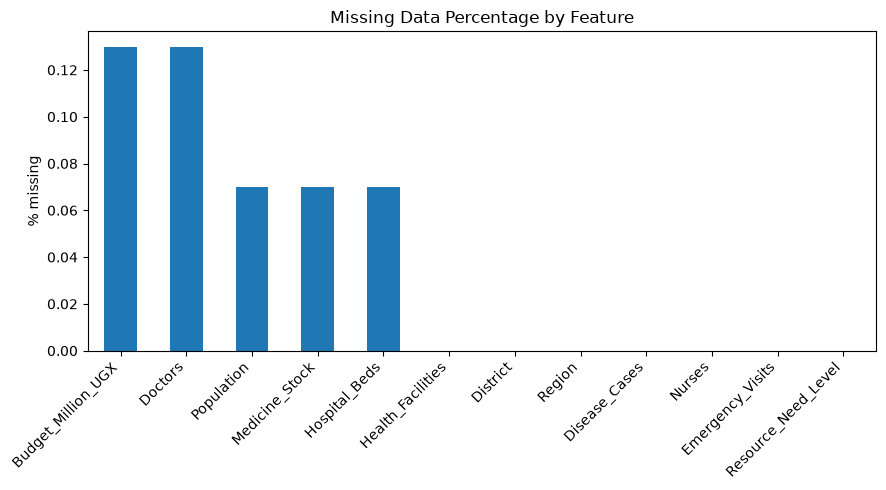

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
missing_summary['missing_%'].sort_values(ascending=False).plot.bar(ax=ax)
ax.set_title('Missing Data Percentage by Feature')
ax.set_ylabel('% missing')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [9]:
#impute missing values using median imputation
cols_to_impute = ['Population', 'Doctors', 'Hospital_Beds', 'Budget_Million_UGX', 'Medicine_Stock']
for col in cols_to_impute:
    if df[col].isna().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"{col}: filled {missing_counts[col]} missing value(s) with median = {median_val}")

Population: filled 1 missing value(s) with median = 473341.0
Doctors: filled 2 missing value(s) with median = 99.0
Hospital_Beds: filled 1 missing value(s) with median = 492.0
Budget_Million_UGX: filled 2 missing value(s) with median = 3976.0
Medicine_Stock: filled 1 missing value(s) with median = 70.0


In [10]:
# Confirm no missing values remain, and that the fill didn't distort the distribution
print("Missing values remaining:\n", df.isna().sum())

print("\nUpdated statistical summary:\n", df[cols_to_impute].describe())



Missing values remaining:
 District               0
Region                 0
Population             0
Health_Facilities      0
Doctors                0
Nurses                 0
Hospital_Beds          0
Disease_Cases          0
Medicine_Stock         0
Emergency_Visits       0
Budget_Million_UGX     0
Resource_Need_Level    0
dtype: int64

Updated statistical summary:
           Population      Doctors  Hospital_Beds  Budget_Million_UGX  \
count    1500.000000  1500.000000    1500.000000         1500.000000   
mean   477552.391333    99.248667     497.824000         4031.870000   
std    246111.246948    56.015772     282.866306         2217.185089   
min     51814.000000    -8.000000      20.000000          201.000000   
25%    262733.000000    49.750000     247.000000         2132.000000   
50%    473341.000000    99.000000     492.000000         3976.000000   
75%    698310.500000   143.250000     739.500000         5926.250000   
max    899988.000000   200.000000    1000.000000     

In [36]:

# Filtering -  districts with High need AND low medicine stock
low_stock_high_need = df[(df["Resource_Need_Level"] == "High") & (df["Medicine_Stock"] < 50)]
print(f"Found {len(low_stock_high_need)} rows matching this condition")
low_stock_high_need.head()

Found 101 rows matching this condition


,Population,Health_Facilities,Doctors,Nurses,Hospital_Beds,Disease_Cases,Medicine_Stock,Emergency_Visits,Budget_Million_UGX,Resource_Need_Level,Region_Central,Region_Eastern,Region_Northern,Region_Western,Doctors_per_1000,Beds_per_1000,Disease_Rate_per_1000,Budget_per_Person,Medicine_per_Facility
9,122103.0,16,74.0,505,733.0,44025,44.0,1094,6189.0,High,False,True,False,False,0.606046,6.003129,360.556252,0.050687,2.750000
26,556098.0,5,127.0,372,838.0,42648,45.0,2064,7652.0,High,False,False,True,False,0.228377,1.506929,76.691518,0.013760,9.000000
32,576017.0,21,141.0,175,556.0,33959,41.0,7311,6561.0,High,False,True,False,False,0.244784,0.965249,58.954857,0.011390,1.952381
35,340368.0,10,30.0,539,483.0,37313,41.0,1138,3831.0,High,False,False,True,False,0.088140,1.419052,109.625464,0.011255,4.100000
41,70429.0,48,146.0,489,471.0,46581,41.0,6397,2915.0,High,False,False,False,True,2.073010,6.687586,661.389484,0.041389,0.854167


In [37]:

#Sorting - find the districts with the highest disease cases
df.sort_values("Disease_Cases", ascending=False).head(10)

,Population,Health_Facilities,Doctors,Nurses,Hospital_Beds,Disease_Cases,Medicine_Stock,Emergency_Visits,Budget_Million_UGX,Resource_Need_Level,Region_Central,Region_Eastern,Region_Northern,Region_Western,Doctors_per_1000,Beds_per_1000,Disease_Rate_per_1000,Budget_per_Person,Medicine_per_Facility
668,425333.0,44,121.0,388,108.0,49960,63.0,3497,6966.0,High,False,True,False,False,0.284483,0.253919,117.460907,0.016378,1.431818
715,284017.0,52,67.0,443,136.0,49937,54.0,235,1137.0,High,False,True,False,False,0.235901,0.478845,175.823982,0.004003,1.038462
1315,284929.0,51,13.0,478,141.0,49922,56.0,6425,616.0,High,False,False,False,True,0.045625,0.494860,175.208561,0.002162,1.098039
153,263029.0,19,13.0,55,992.0,49898,80.0,1533,6958.0,High,False,False,True,False,0.049424,3.771447,189.705318,0.026453,4.210526
1096,187472.0,18,107.0,538,609.0,49885,57.0,6608,6232.0,High,False,True,False,False,0.570752,3.248485,266.093070,0.033242,3.166667
800,780563.0,53,26.0,30,609.0,49802,41.0,9753,4666.0,High,False,False,False,True,0.033309,0.780206,63.802666,0.005978,0.773585
880,660253.0,50,94.0,416,632.0,49754,47.0,5638,2905.0,High,True,False,False,False,0.142370,0.957209,75.355962,0.004400,0.940000
565,767288.0,9,81.0,90,892.0,49696,82.0,5683,3782.0,High,False,True,False,False,0.105567,1.162536,64.768379,0.004929,9.111111
212,616211.0,75,129.0,410,225.0,49664,86.0,3934,2735.0,High,True,False,False,False,0.209344,0.365135,80.595770,0.004438,1.146667
1054,521686.0,22,73.0,151,372.0,49605,87.0,5268,6360.0,High,True,False,False,False,0.139931,0.713073,95.085933,0.012191,3.954545


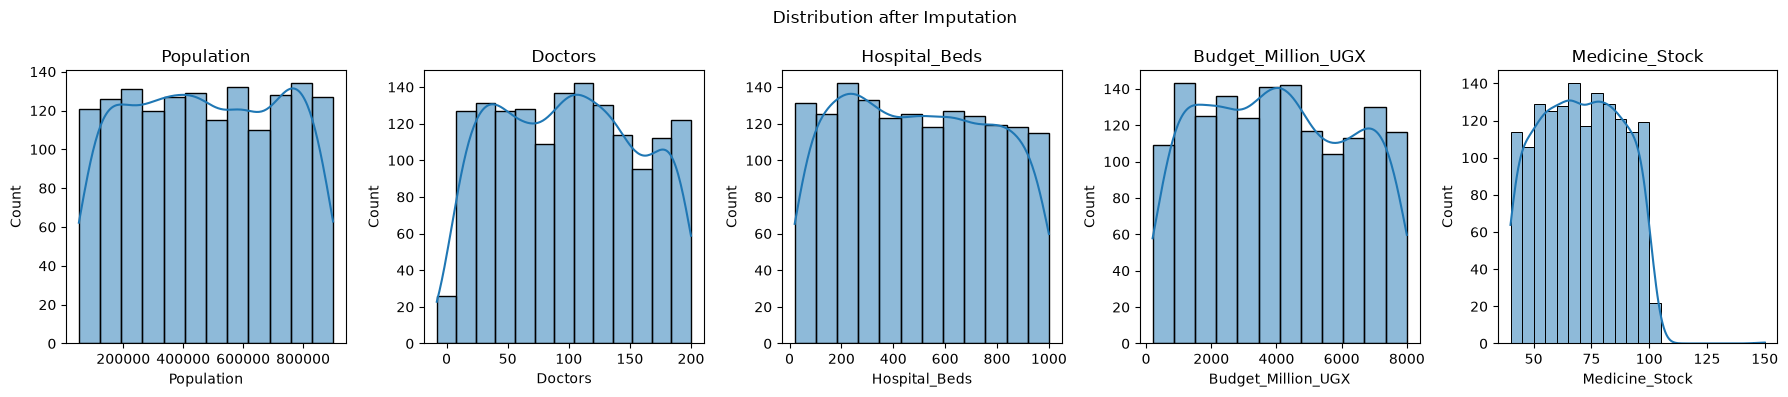

In [11]:

fig, axes = plt.subplots(1, len(cols_to_impute), figsize=(18, 4))
for ax, col in zip(axes, cols_to_impute):
    sns.histplot(before_describe(col) if False else df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.suptitle('Distribution after Imputation')
plt.tight_layout()
plt.show()



C:\Users\LINET\AppData\Local\Temp\ipykernel_13180\941793386.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='District', y='Population', data=df, errorbar=None, palette='viridis')


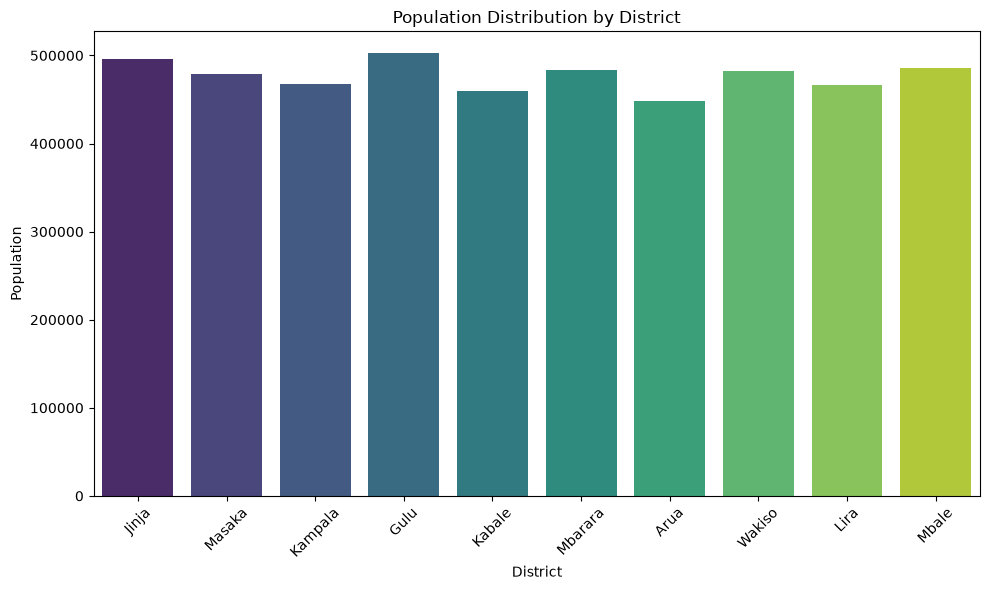

In [12]:
#A barplot for districts against population
plt.figure(figsize=(10, 6))
sns.barplot(x='District', y='Population', data=df, errorbar=None, palette='viridis')
plt.title('Population Distribution by District')
plt.xlabel('District')
plt.ylabel('Population')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


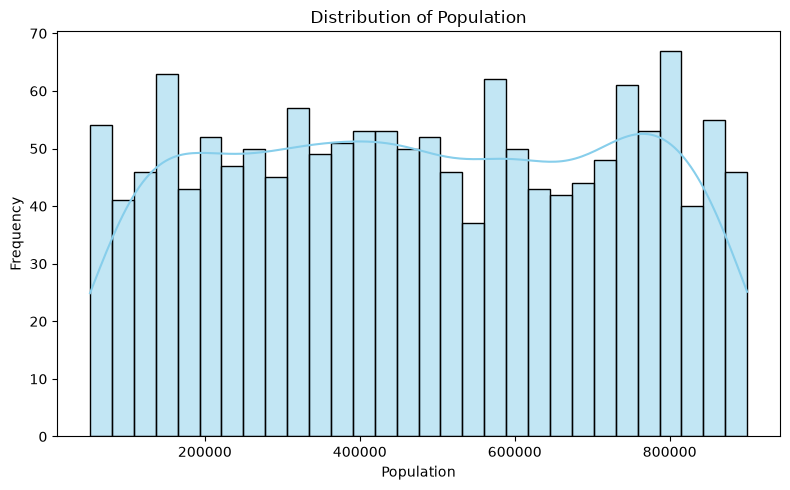

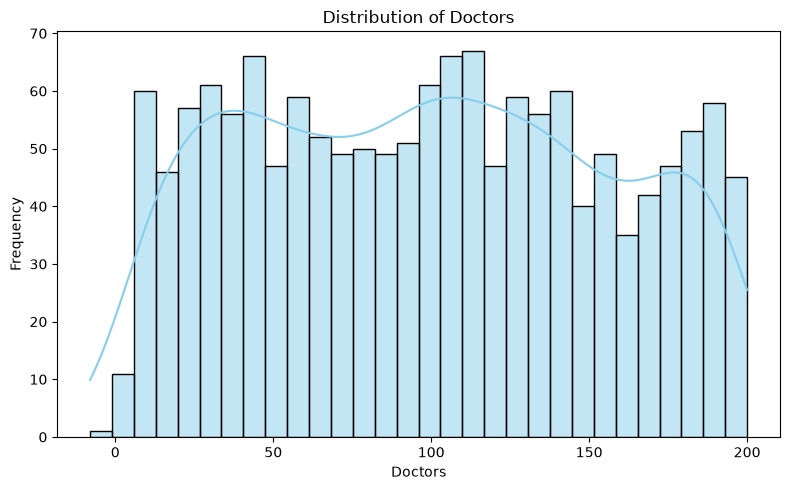

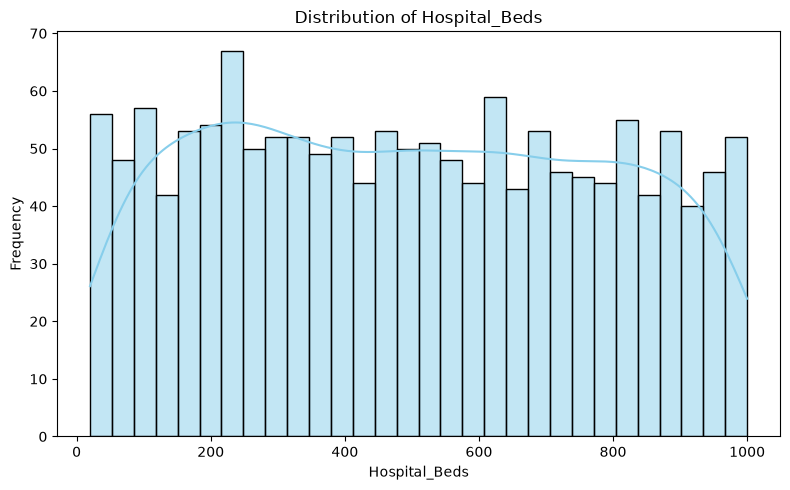

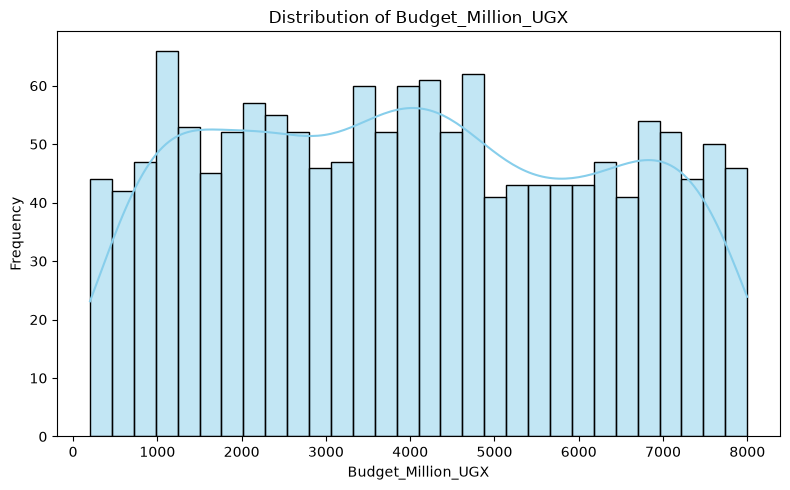

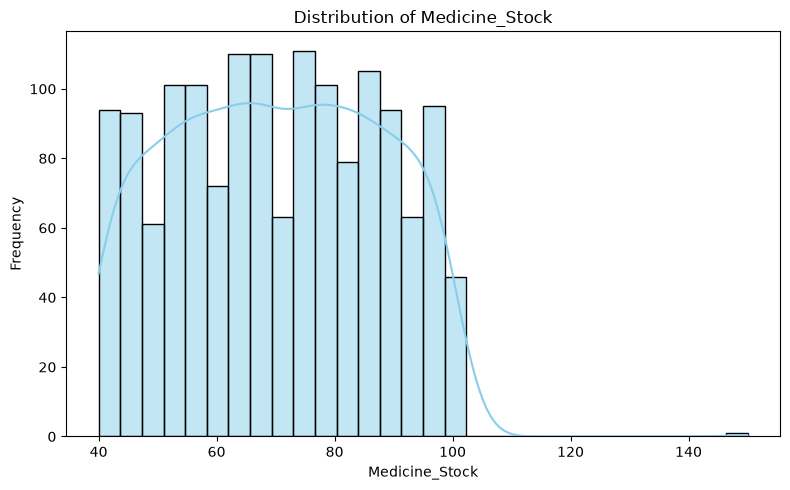

In [13]:
#distribution analysis for doctors, hospital beds, budget, and medicine stock
for col in cols_to_impute:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

C:\Users\LINET\AppData\Local\Temp\ipykernel_13180\2074089120.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='District', y=col, data=df, errorbar=None, palette='coolwarm')


<Figure size 1000x600 with 0 Axes>

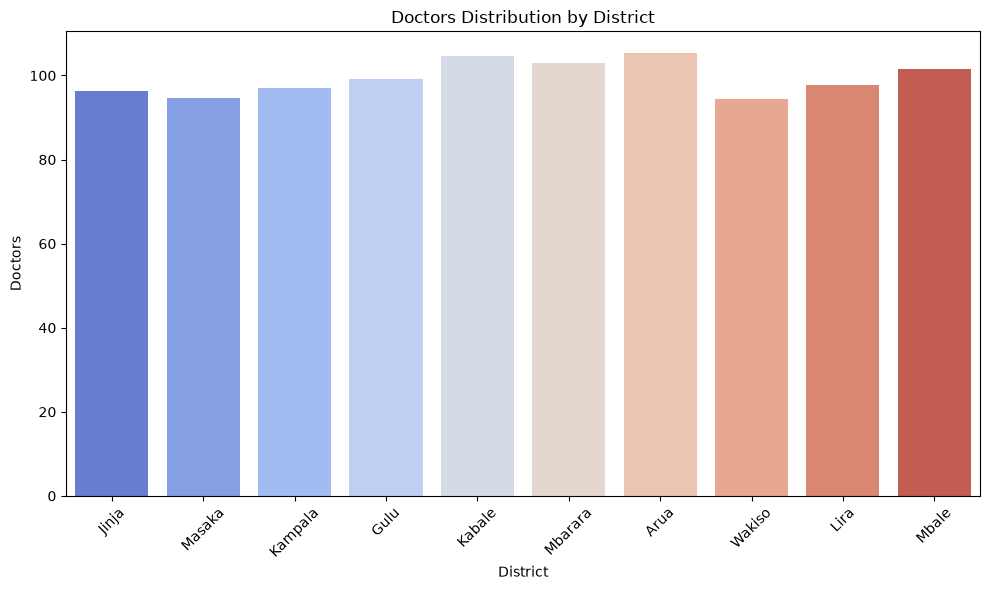

C:\Users\LINET\AppData\Local\Temp\ipykernel_13180\2074089120.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='District', y=col, data=df, errorbar=None, palette='coolwarm')


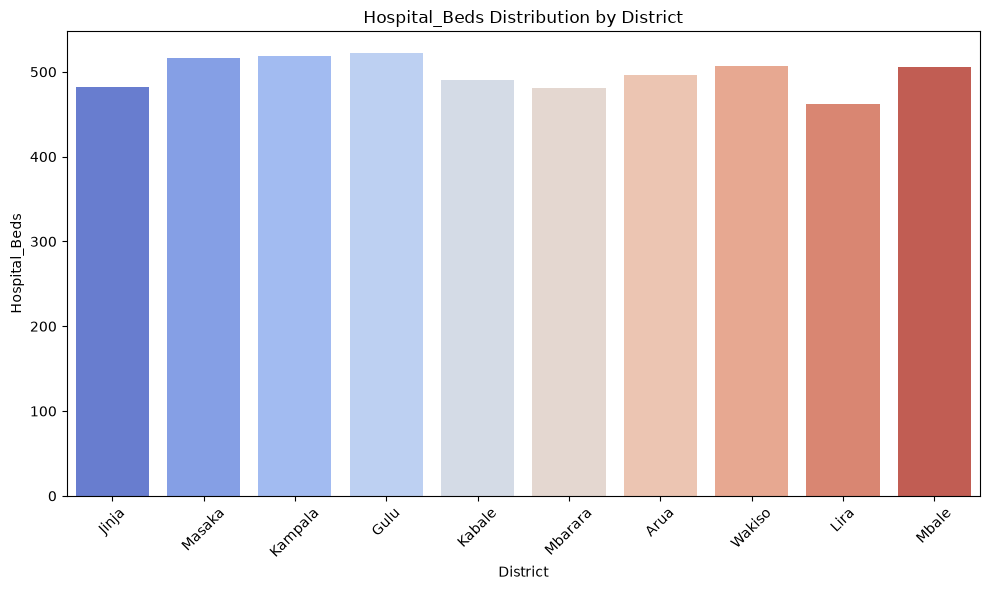

C:\Users\LINET\AppData\Local\Temp\ipykernel_13180\2074089120.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='District', y=col, data=df, errorbar=None, palette='coolwarm')


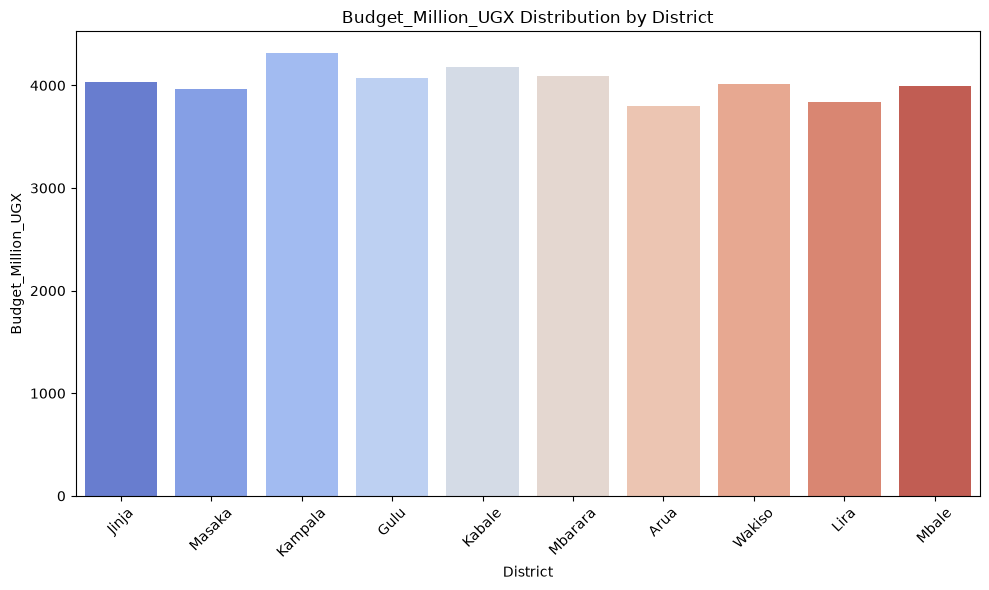

C:\Users\LINET\AppData\Local\Temp\ipykernel_13180\2074089120.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='District', y=col, data=df, errorbar=None, palette='coolwarm')


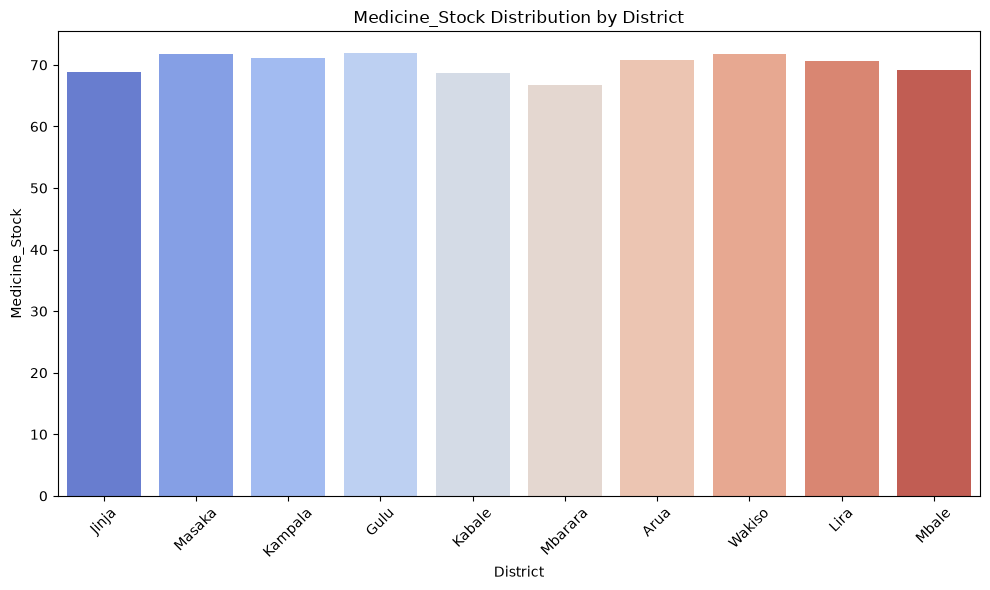

In [14]:
#comparing resource allocation across districts using barplots for doctors, hospital beds, budget, and medicine stock
for col in cols_to_impute:
    plt.figure(figsize=(10, 6))
    #exclude population distribution as it has already been plotted
    if col != 'Population':
        sns.barplot(x='District', y=col, data=df, errorbar=None, palette='coolwarm')
        plt.title(f'{col} Distribution by District')
        plt.xlabel('District')
        plt.ylabel(col)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

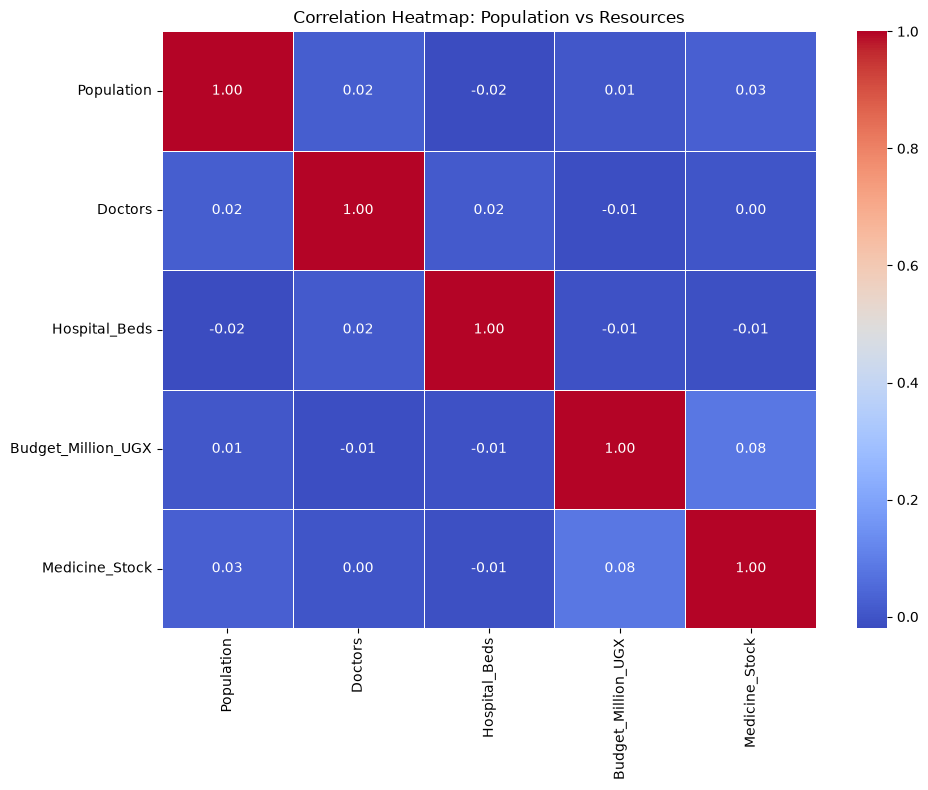

In [15]:
plt.figure(figsize=(10, 8))
corr_matrix = df[cols_to_impute].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap: Population vs Resources')
plt.tight_layout()
plt.show()

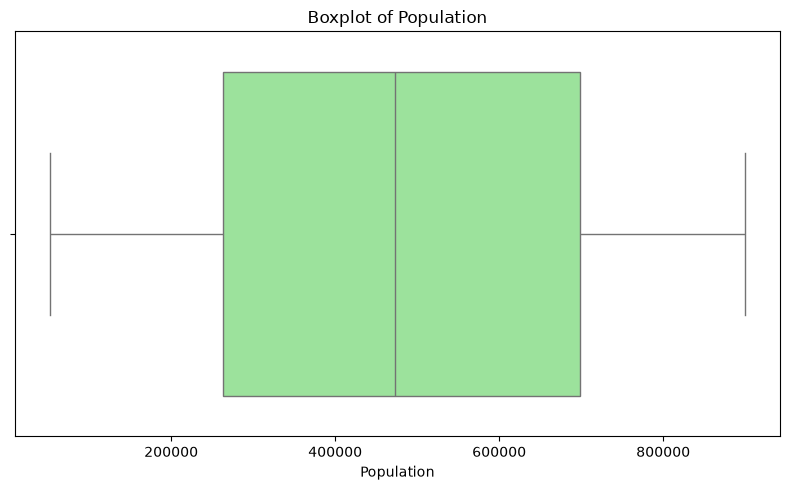

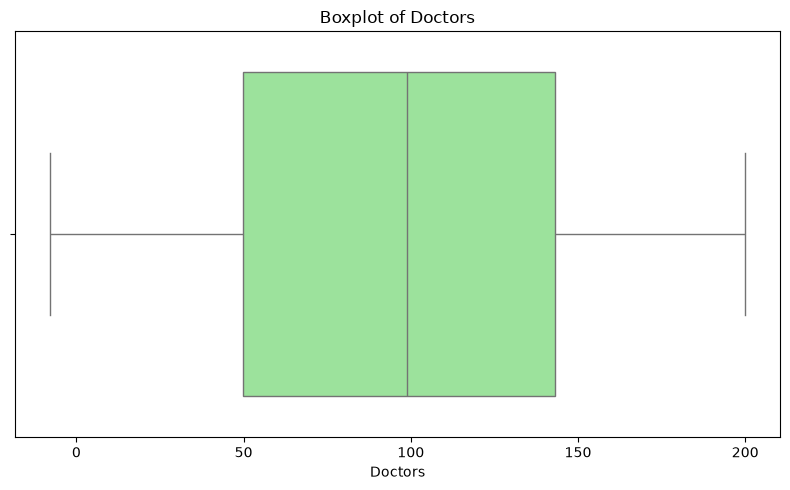

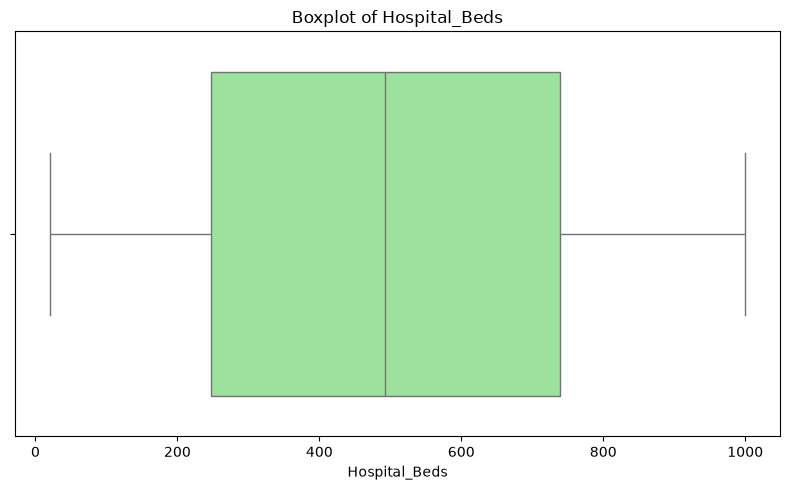

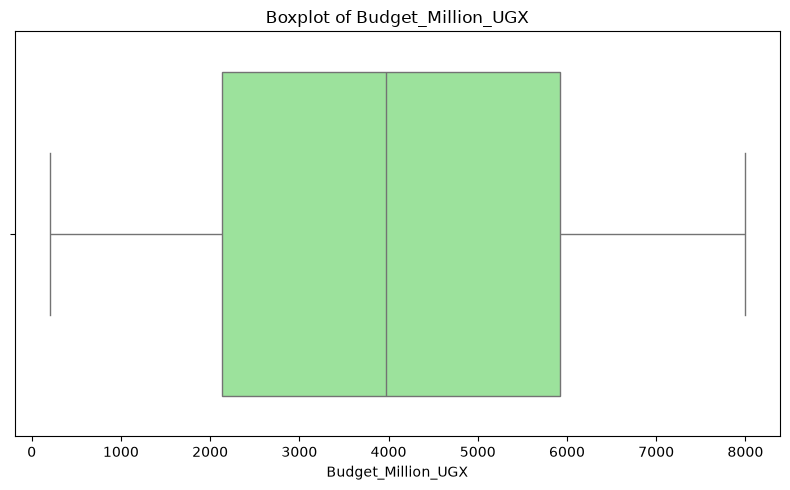

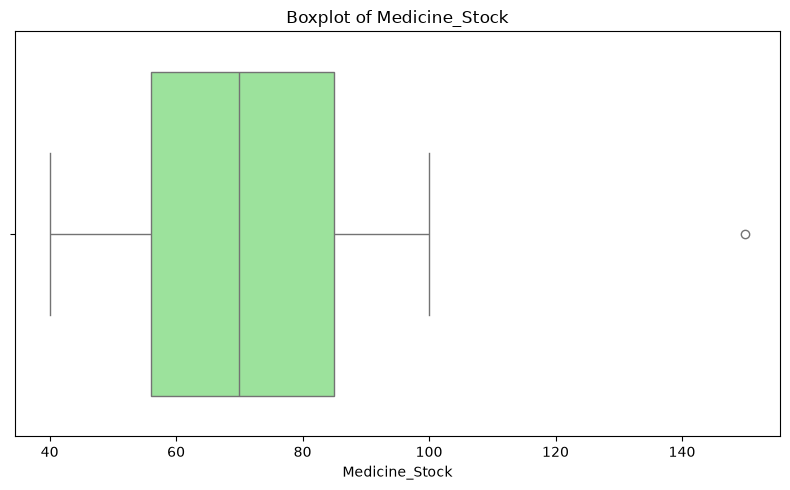

In [16]:
#outlier detection using boxplots for doctors, hospital beds, budget, and medicine stock
for col in cols_to_impute:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=df[col], color='lightgreen')
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

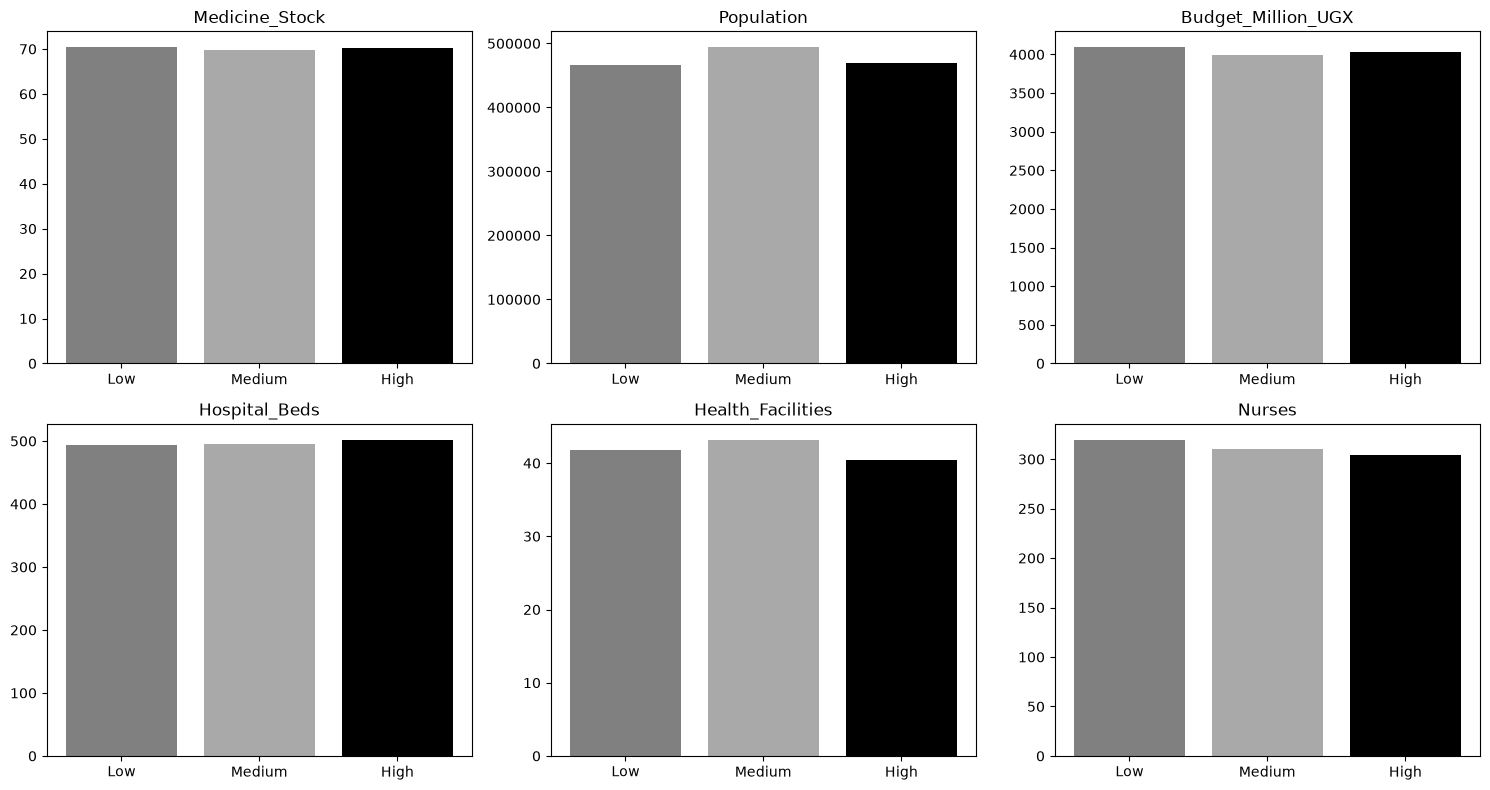

In [35]:
# %%
# The 6 "noise" columns we're checking
noise_cols = ['Medicine_Stock', 'Population', 'Budget_Million_UGX',
              'Hospital_Beds', 'Health_Facilities', 'Nurses']

# Create a grid of 6 small charts (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()  # turns the 2x3 grid into a simple list of 6 slots

# %%
# Loop through each noisy column and draw its own bar chart
for i, col in enumerate(noise_cols):
    avg_by_need = df.groupby('Resource_Need_Level')[col].mean()
    avg_by_need = avg_by_need.reindex(['Low', 'Medium', 'High'])
    
    axes[i].bar(avg_by_need.index, avg_by_need.values, color=['gray', 'darkgray', 'black'])
    axes[i].set_title(col)

plt.tight_layout()  # stops the charts from overlapping each other
plt.show()

In [26]:
#  Calculate the average Disease_Cases for each need level
avg_disease = df.groupby('Resource_Need_Level')['Disease_Cases'].mean()
avg_disease = avg_disease.reindex(['Low', 'Medium', 'High'])

print(avg_disease)

Resource_Need_Level
Low        6465.952978
Medium    21032.787938
High      37511.029985
Name: Disease_Cases, dtype: float64


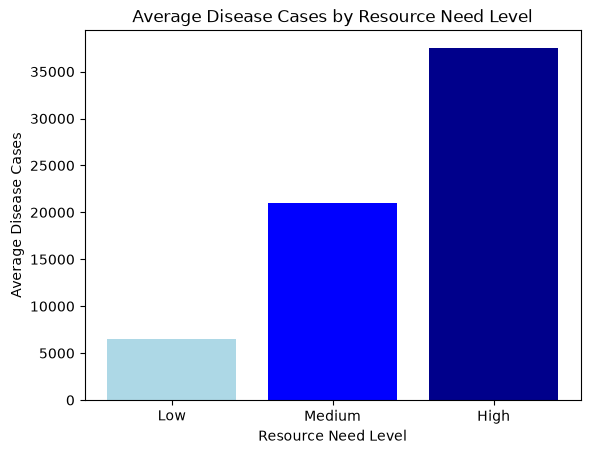

In [30]:
# Step 3: Plot it as a bar chart
plt.bar(avg_disease.index, avg_disease.values, color=['lightblue', 'blue', 'darkblue'])
plt.title('Average Disease Cases by Resource Need Level')
plt.xlabel('Resource Need Level')
plt.ylabel('Average Disease Cases')
plt.show()

In [28]:
# Step 1: Average Doctors per need level
avg_doctors = df.groupby('Resource_Need_Level')['Doctors'].mean()

# Step 2: Put it in logical order (Low, Medium, High)
avg_doctors = avg_doctors.reindex(['Low', 'Medium', 'High'])

print(avg_doctors)

Resource_Need_Level
Low       108.018809
Medium    109.367704
High       87.256372
Name: Doctors, dtype: float64


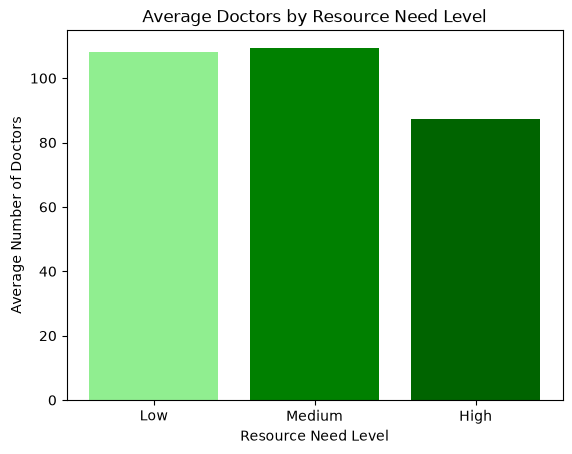

In [29]:
# Step 3: Plot it
plt.bar(avg_doctors.index, avg_doctors.values, color=['lightgreen', 'green', 'darkgreen'])
plt.title('Average Doctors by Resource Need Level')
plt.xlabel('Resource Need Level')
plt.ylabel('Average Number of Doctors')
plt.show()

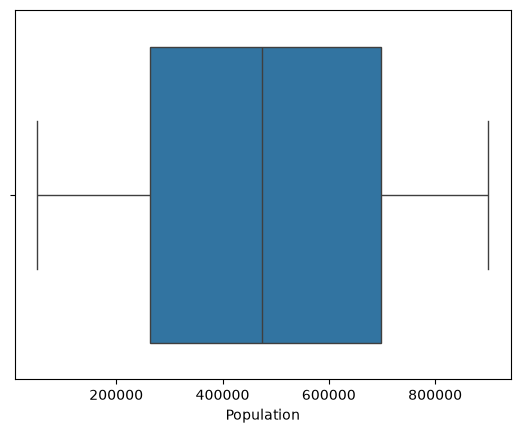

In [21]:
sns.boxplot(x=df['Population'])
plt.show()